# 🍷 Wine Quality Prediction — End-to-End ML Project

**Goal:** Predict whether a wine is *GOOD* (quality ≥ 7) or *BAD* (quality < 7) using its physicochemical properties.

**Pipeline:**
1. Load data & basic EDA (`head`, `info`, `describe`)
2. Missing value check & correlation analysis
3. Create binary target `quality_label`
4. Train/test split
5. Logistic Regression — unscaled vs scaled
6. Compare Logistic Regression, KNN, Decision Tree
7. Hyperparameter tuning (GridSearchCV) on the best model
8. Feature importance analysis


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, ConfusionMatrixDisplay,
                              classification_report)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)
pd.set_option('display.max_columns', None)


## 1. Load Dataset & Basic Exploration

In [2]:
# In Colab, upload winequality.csv first (or mount Drive), then update the path below.
df = pd.read_csv('winequality.csv')
df.head()


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [4]:
df.describe()


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


## 2. Missing Values & Correlation Analysis

In [5]:
# Missing value check
missing = df.isnull().sum()
print("Missing values per column:")
print(missing)
print(f"\nTotal missing values: {missing.sum()}")


Missing values per column:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

Total missing values: 0


Correlation of features with quality:

quality                 1.000000
alcohol                 0.476166
sulphates               0.251397
citric acid             0.226373
fixed acidity           0.124052
residual sugar          0.013732
free sulfur dioxide    -0.050656
pH                     -0.057731
chlorides              -0.128907
density                -0.174919
total sulfur dioxide   -0.185100
volatile acidity       -0.390558
Name: quality, dtype: float64


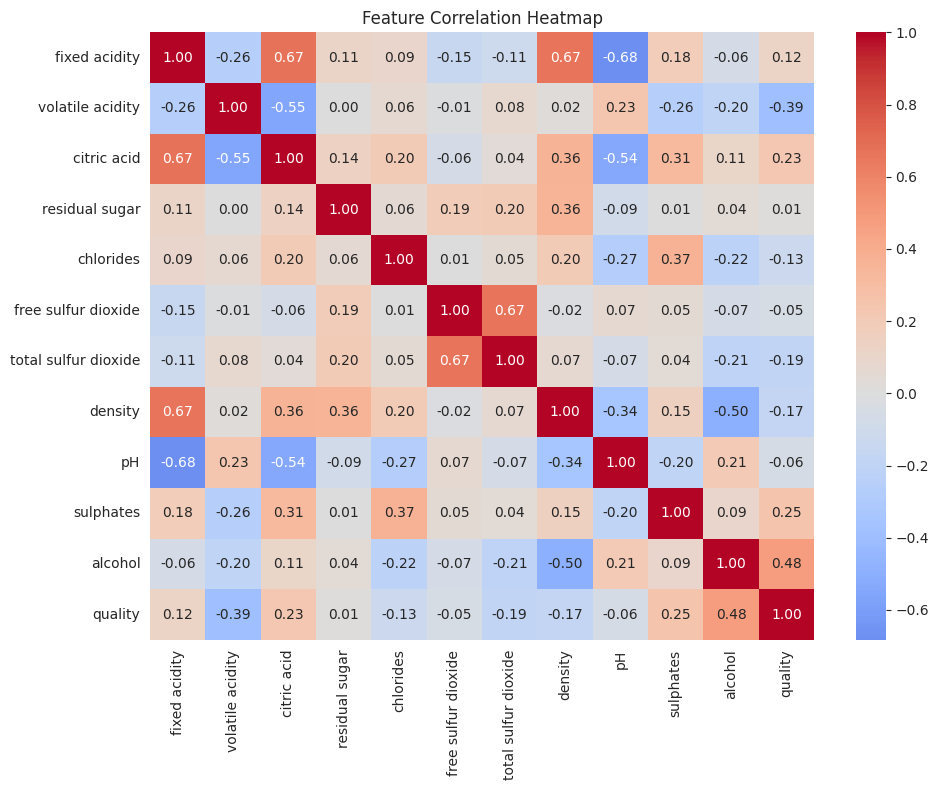

In [6]:
# Correlation of every feature with 'quality'
corr = df.corr(numeric_only=True)
quality_corr = corr['quality'].sort_values(ascending=False)
print("Correlation of features with quality:\n")
print(quality_corr)

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()


**Insight:** `alcohol`, `sulphates`, and `citric acid` tend to correlate positively with quality, while `volatile acidity` correlates negatively — these are early signals of which features will matter for feature importance later.

## 3. Create Binary Target: `quality_label`

quality_label
0    1382
1     217
Name: count, dtype: int64

GOOD wine %: 13.57%


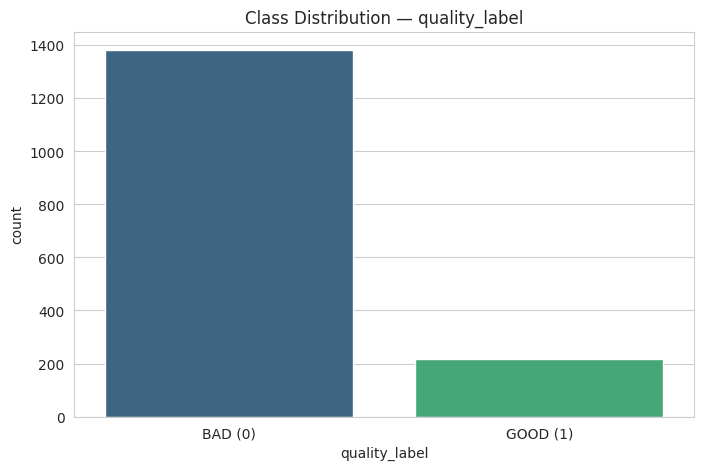

In [7]:
# quality >= 7 -> GOOD (1), quality < 7 -> BAD (0)
df['quality_label'] = (df['quality'] >= 7).astype(int)

print(df['quality_label'].value_counts())
print(f"\nGOOD wine %: {df['quality_label'].mean()*100:.2f}%")

sns.countplot(x='quality_label', data=df, hue='quality_label', palette='viridis', legend=False)
plt.xticks([0, 1], ['BAD (0)', 'GOOD (1)'])
plt.title('Class Distribution — quality_label')
plt.show()


**Note:** The classes are imbalanced (far more BAD wines than GOOD). We use `stratify=y` in the train/test split so both sets keep the same class ratio, and we look at precision/recall/F1 — not just accuracy — because accuracy alone can be misleading on imbalanced data.

## 4. Feature/Target Split & Train-Test Split

In [8]:
X = df.drop(columns=['quality', 'quality_label'])
y = df['quality_label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")


Train shape: (1279, 11), Test shape: (320, 11)


## 5. Logistic Regression — Without Scaling

In [9]:
def evaluate(model_name, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    print(f"--- {model_name} ---")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-score : {f1:.4f}")
    cm = confusion_matrix(y_true, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=['BAD', 'GOOD']).plot(cmap='Blues')
    plt.title(f'Confusion Matrix — {model_name}')
    plt.show()
    return {'model': model_name, 'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1}


--- Logistic Regression (Unscaled) ---
Accuracy : 0.8938
Precision: 0.7368
Recall   : 0.3256
F1-score : 0.4516


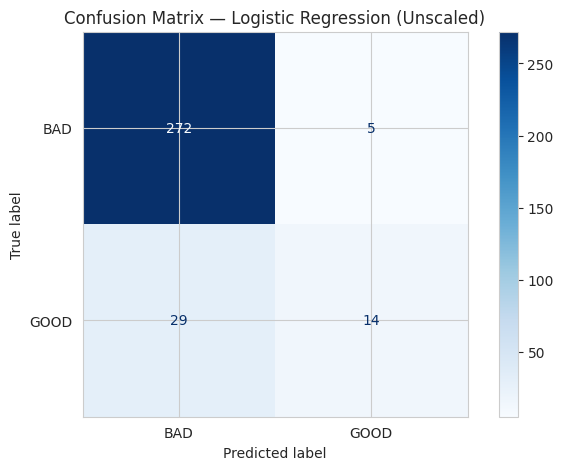

In [10]:
log_reg_raw = LogisticRegression(max_iter=1000, random_state=42)
log_reg_raw.fit(X_train, y_train)
pred_raw = log_reg_raw.predict(X_test)

results_unscaled = evaluate('Logistic Regression (Unscaled)', y_test, pred_raw)


## 6. Apply StandardScaler & Retrain

--- Logistic Regression (Scaled) ---
Accuracy : 0.8938
Precision: 0.6957
Recall   : 0.3721
F1-score : 0.4848


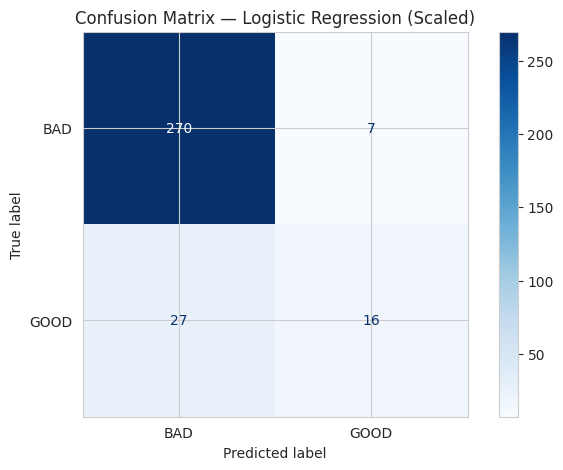

In [11]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_reg_scaled = LogisticRegression(max_iter=1000, random_state=42)
log_reg_scaled.fit(X_train_scaled, y_train)
pred_scaled = log_reg_scaled.predict(X_test_scaled)

results_scaled = evaluate('Logistic Regression (Scaled)', y_test, pred_scaled)


In [12]:
compare_scaling = pd.DataFrame([results_unscaled, results_scaled]).set_index('model')
compare_scaling


,accuracy,precision,recall,f1
model,,,,
Logistic Regression (Unscaled),0.89375,0.736842,0.325581,0.451613
Logistic Regression (Scaled),0.89375,0.695652,0.372093,0.484848


**Before vs After Scaling:** Logistic Regression uses gradient-based optimization and distance-like coefficient penalties, so it's sensitive to feature scale. Scaling usually speeds up convergence and can shift metrics slightly — compare the table above to see the effect on this dataset.

## 7. Model Comparison: Logistic Regression vs KNN vs Decision Tree

--- Logistic Regression ---
Accuracy : 0.8938
Precision: 0.6957
Recall   : 0.3721
F1-score : 0.4848


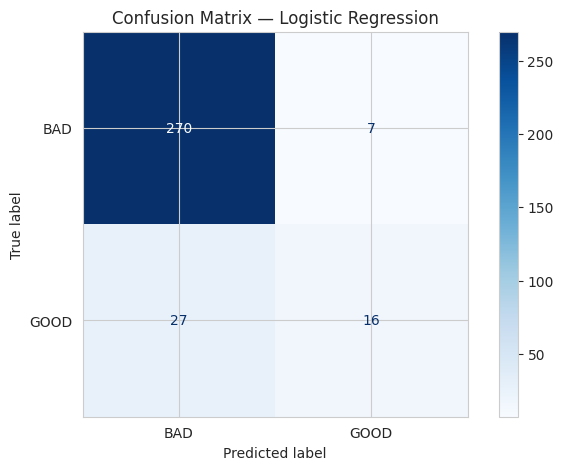

--- KNN ---
Accuracy : 0.8938
Precision: 0.6667
Recall   : 0.4186
F1-score : 0.5143


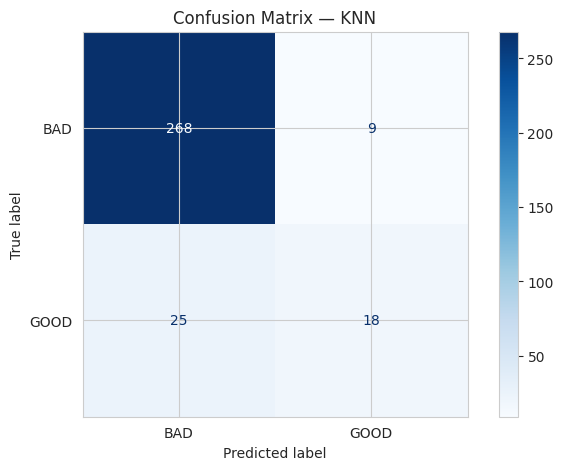

--- Decision Tree ---
Accuracy : 0.9062
Precision: 0.6383
Recall   : 0.6977
F1-score : 0.6667


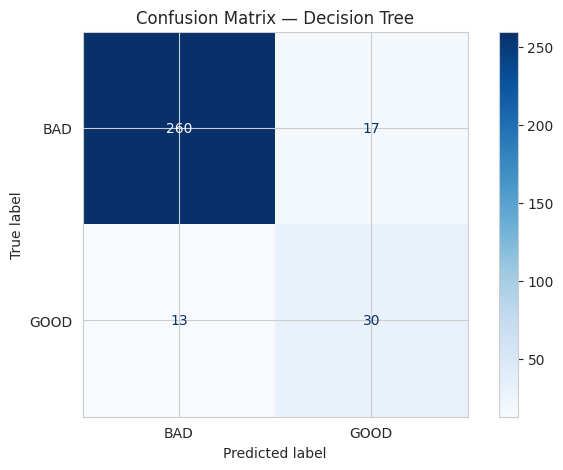

In [13]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'Decision Tree': DecisionTreeClassifier(random_state=42)
}

all_results = []
trained_models = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    pred = model.predict(X_test_scaled)
    res = evaluate(name, y_test, pred)
    all_results.append(res)
    trained_models[name] = model


In [14]:
comparison_df = pd.DataFrame(all_results).set_index('model').sort_values('f1', ascending=False)
comparison_df


,accuracy,precision,recall,f1
model,,,,
Decision Tree,0.90625,0.638298,0.697674,0.666667
KNN,0.89375,0.666667,0.418605,0.514286
Logistic Regression,0.89375,0.695652,0.372093,0.484848


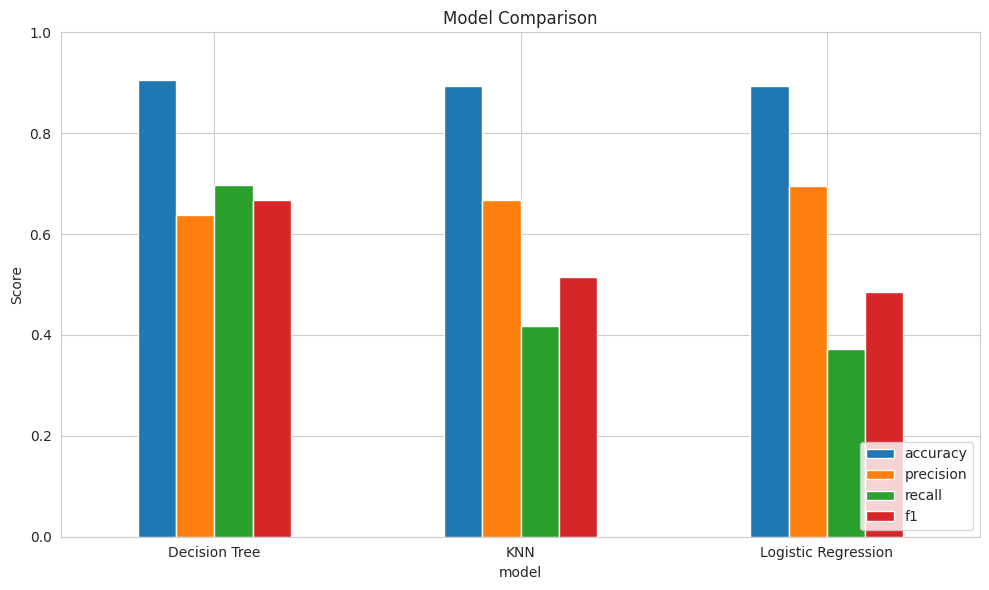


Best model based on F1-score: Decision Tree


In [15]:
comparison_df[['accuracy', 'precision', 'recall', 'f1']].plot(kind='bar', figsize=(10, 6))
plt.title('Model Comparison')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

best_model_name = comparison_df['f1'].idxmax()
print(f"\nBest model based on F1-score: {best_model_name}")


## 8. Hyperparameter Tuning (GridSearchCV) on the Best Model

Best params: {'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best CV F1-score: 0.5274
--- Decision Tree (Tuned) ---
Accuracy : 0.9250
Precision: 0.7317
Recall   : 0.6977
F1-score : 0.7143


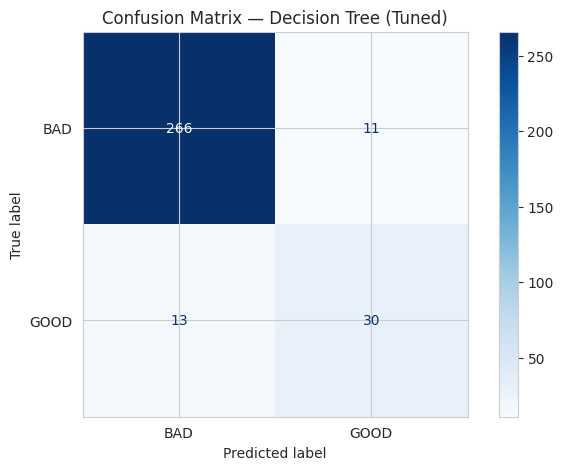

In [16]:
# Parameter grids for each candidate model, keyed by name so this adapts
# automatically to whichever model scored best above.
param_grids = {
    'Logistic Regression': {
        'C': [0.01, 0.1, 1, 10, 100],
        'penalty': ['l2'],
        'solver': ['lbfgs']
    },
    'KNN': {
        'n_neighbors': [3, 5, 7, 9, 11],
        'weights': ['uniform', 'distance'],
        'p': [1, 2]
    },
    'Decision Tree': {
        'max_depth': [3, 5, 7, 10, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4],
        'criterion': ['gini', 'entropy']
    }
}

base_model = models[best_model_name]
grid = GridSearchCV(base_model, param_grids[best_model_name], cv=5, scoring='f1', n_jobs=-1)
grid.fit(X_train_scaled, y_train)

print(f"Best params: {grid.best_params_}")
print(f"Best CV F1-score: {grid.best_score_:.4f}")

tuned_model = grid.best_estimator_
pred_tuned = tuned_model.predict(X_test_scaled)
results_tuned = evaluate(f'{best_model_name} (Tuned)', y_test, pred_tuned)


In [17]:
final_comparison = pd.concat([
    comparison_df.reset_index(),
    pd.DataFrame([results_tuned])
], ignore_index=True).set_index('model')
final_comparison


,accuracy,precision,recall,f1
model,,,,
Decision Tree,0.90625,0.638298,0.697674,0.666667
KNN,0.89375,0.666667,0.418605,0.514286
Logistic Regression,0.89375,0.695652,0.372093,0.484848
Decision Tree (Tuned),0.92500,0.731707,0.697674,0.714286


## 9. Feature Importance Analysis

alcohol                 0.285914
sulphates               0.101674
volatile acidity        0.097330
pH                      0.086588
total sulfur dioxide    0.078875
chlorides               0.071724
residual sugar          0.071398
citric acid             0.061351
free sulfur dioxide     0.058129
density                 0.053257
fixed acidity           0.033761
dtype: float64


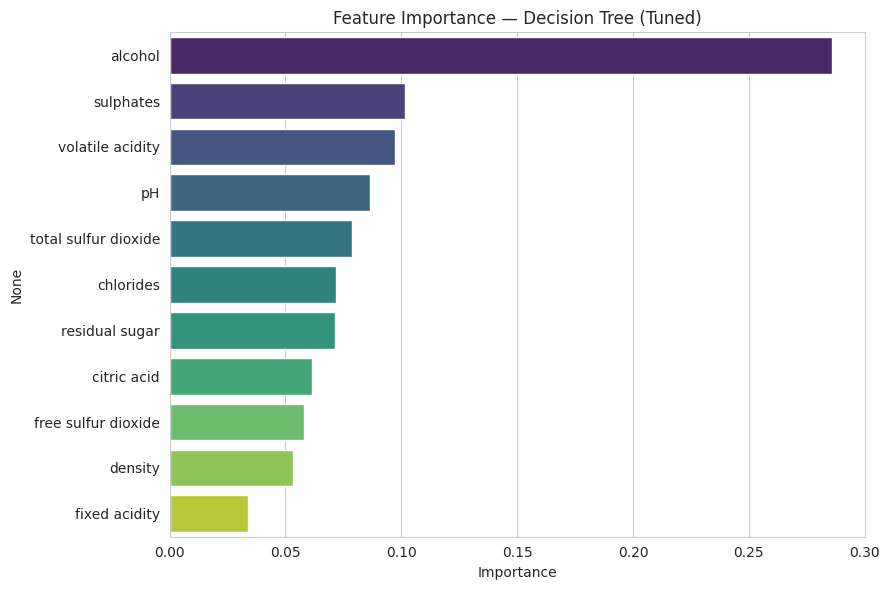

In [18]:
# Works whether the tuned model is tree-based (feature_importances_)
# or linear (coef_).
feature_names = X.columns

if hasattr(tuned_model, 'feature_importances_'):
    importances = tuned_model.feature_importances_
elif hasattr(tuned_model, 'coef_'):
    importances = np.abs(tuned_model.coef_[0])
else:
    # KNN has no built-in importance -> fall back to a Decision Tree
    # trained on the same data purely to rank features.
    fallback = DecisionTreeClassifier(random_state=42).fit(X_train_scaled, y_train)
    importances = fallback.feature_importances_

feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)
print(feat_imp)

plt.figure(figsize=(9, 6))
sns.barplot(x=feat_imp.values, y=feat_imp.index, hue=feat_imp.index, palette='viridis', legend=False)
plt.title(f'Feature Importance — {best_model_name} (Tuned)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()


**Conclusion:** The bar chart above ranks which physicochemical properties most influence whether a wine is classified as GOOD vs BAD. Typically `alcohol`, `volatile acidity`, and `sulphates` come out on top — matching the correlation analysis from Section 2. This closes the loop from raw EDA → modeling → interpretability.